# Lecture 25: Moment Map in Gauge Theory

**Source span actually read.** `pdftotext` verified that physical PDF pages 163-171 contain printed pages 153-161: Lecture 25 from "Moment Map in Gauge Theory" through Homework 19. The earlier inventory note `physical 167-175` is shifted by four pages; that window starts at printed page 157 and runs into Lecture 26.

**Chapter goal.** Build the Atiyah-Bott slogan in an inspectable model: the affine space of connections carries a symplectic form, the gauge group acts by shifting connections, and the moment map is curvature. The finite grid below is only a toy model of the infinite-dimensional story, but every displayed residual is the same witness used in the lecture: curvature ignores exact gauge shifts, and Stokes' theorem turns the moment-map derivative into the symplectic pairing with an infinitesimal gauge vector.


In [1]:
from pathlib import Path
import json
import math
import sys

import numpy as np


def find_book_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    candidates = []
    for base in [start, *start.parents]:
        candidates.append(base)
        candidates.append(base / "Lectures-on-Symplectic-Geometry")
    for candidate in candidates:
        if (candidate / "AGENTS.md").exists() and (candidate / "Lectures on Symplectic Geometry.pdf").exists():
            return candidate.resolve()
    raise RuntimeError("Could not locate the Lectures-on-Symplectic-Geometry course root.")


BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import display_artifact, read_json, save_json

LECTURE = "lecture-25"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / LECTURE
FIGURES = ARTIFACT_ROOT / "figures"
INTERACTIVE = ARTIFACT_ROOT / "interactive"
CHECKS = ARTIFACT_ROOT / "checks"
for directory in [FIGURES, INTERACTIVE, CHECKS]:
    directory.mkdir(parents=True, exist_ok=True)

print({"book_root": str(BOOK_ROOT), "artifact_root": str(ARTIFACT_ROOT.relative_to(BOOK_ROOT))})


{'book_root': 'D:\\Geometry\\Lectures-on-Symplectic-Geometry', 'artifact_root': 'artifacts\\lecture-25'}


## Library Routing

NetworkX is used for the principal-bundle-to-curvature dependency route because the lecture is an infinite-dimensional construction with a precise conceptual spine. Matplotlib displays the circle-bundle gauge shift and finite Fourier symplectic pairing matrix, where curvature invariance and nondegeneracy can be inspected directly. Plotly supplies the gauge-amplitude lab as a safe finite-grid proxy for moving connections while preserving curvature residuals. NumPy performs the periodic-grid Stokes and rank checks that stand in for the analytic Atiyah-Bott identities.

## Translation Guide

The source lecture moves through five linked constructions.

- A principal bundle `G -> P -> B` supplies vertical directions: infinitesimal group orbits inside `TP`.
- A connection is a `G`-invariant horizontal complement `H`, or equivalently a Lie-algebra-valued one-form `A` whose kernel is `H` and whose value on vertical generators is the generator itself.
- Curvature is the horizontal part of `dA`. In the circle-bundle model this becomes the ordinary two-form `dA` on the base.
- The space of all connections is affine. Once a reference connection is fixed, variations are horizontal one-forms, so a tangent vector to the space of connections can be drawn as a one-form on the base.
- Gauge transformations act on connections. For circle bundles over a surface, a phase function `theta` changes a connection by `A -> A - d theta`; the curvature does not change.

The lecture's moment-map identity is therefore a Stokes theorem in disguise. For `X in C^infty(B)` and a variation `a in Omega^1(B)`, the two sides are

```text
d mu_X(a) = integral_B X d a,
omega(X#, a) = integral_B (-dX) wedge a.
```

On a closed oriented surface these are equal because the integral of `d(Xa)` vanishes. The plots below make each term visible on a periodic square, a flat model of a closed surface with no boundary contribution.


In [2]:
source_span = {
    "title": "Lecture 25: Moment Map in Gauge Theory",
    "printed_pages_read": "153-161",
    "physical_pdf_pages_read": "163-171",
    "verification": "pdftotext header scan found the Lecture 25 title, sections 25.1-25.5, Homework 19, and Lecture 26 beginning after printed page 161.",
    "inventory_note": "The supplied inventory physical span 167-175 is shifted; it starts at printed page 157 and crosses into Lecture 26.",
}

storyboard = {
    "chapter_goal": "Explain why curvature is the moment map for the gauge action on the affine space of connections, with the circle-bundle case as the executable model.",
    "source_span_read": source_span,
    "concept_inventory": [
        "principal bundle and vertical directions",
        "connection as horizontal complement / connection form",
        "curvature as the horizontal component of dA",
        "affine space of connections modeled on horizontal one-forms",
        "Atiyah-Bott symplectic form by integrating wedge products over the base surface",
        "gauge action A -> A - d theta in the S1 case",
        "moment-map identity d mu_X(a) = omega(X#, a)",
        "flat connections modulo gauge transformations as the zero-level reduced space",
    ],
    "library_routing_table": [
        {
            "concept": "proof dependency route",
            "representation": "directed graph",
            "library": "networkx + matplotlib",
            "why": "the lecture is proof-structural; a graph makes the dependencies leading to mu(A)=curv(A) inspectable",
            "fallback": "SVG boxes and arrows",
        },
        {
            "concept": "circle-bundle gauge action",
            "representation": "periodic-grid one-form, gauge potential, and curvature residual",
            "library": "numpy + matplotlib",
            "why": "the base is two-dimensional and the invariant is an integral/derivative residual on a grid",
            "fallback": "saved CSV/JSON tables",
        },
        {
            "concept": "Atiyah-Bott symplectic pairing",
            "representation": "finite Fourier subspace pairing matrix",
            "library": "numpy + matplotlib",
            "why": "a small skew matrix exposes bilinearity, skewness, and nondegeneracy on sampled modes",
            "fallback": "plain JSON matrix",
        },
        {
            "concept": "gauge parameter exploration",
            "representation": "HTML slider showing connection changes while curvature stays fixed",
            "library": "plotly",
            "why": "the learner should vary the gauge amplitude and watch which quantity changes and which one does not",
            "fallback": "static before/after PNG",
        },
    ],
    "visual_sequence": [
        {
            "concept": "Lecture dependency route",
            "artifact": "artifacts/lecture-25/figures/lecture-25-dependency-route.png",
            "inspection_target": "follow the arrows from principal bundle data to the curvature moment map and the zero-level quotient",
            "validation": "graph contains all five source sections and the moment-map node has incoming edges from curvature, symplectic form, and gauge action",
        },
        {
            "concept": "Gauge shift leaves curvature unchanged",
            "artifact": "artifacts/lecture-25/figures/lecture-25-circle-gauge-curvature.png",
            "inspection_target": "compare A and A-dtheta while checking that the curvature-difference panel stays numerically zero",
            "validation": "max |F(A-dtheta)-F(A)| is below numerical tolerance",
        },
        {
            "concept": "Symplectic form on a finite space of one-forms",
            "artifact": "artifacts/lecture-25/figures/lecture-25-symplectic-pairing-matrix.png",
            "inspection_target": "read the skew pairing blocks produced by integrating a wedge b over the base",
            "validation": "pairing matrix is skew and nonsingular on the chosen eight-dimensional Fourier subspace",
        },
        {
            "concept": "Interactive gauge parameter lab",
            "artifact": "artifacts/lecture-25/interactive/lecture-25-gauge-shift-lab.html",
            "inspection_target": "move the gauge-amplitude slider and observe that the connection component changes but curvature residual remains zero",
            "validation": "stored frame residuals remain below tolerance",
        },
    ],
    "computational_checks": [
        "periodic-grid curvature invariance under A -> A - dtheta",
        "finite-dimensional skew-symmetry and singular-value check for integral wedge pairing",
        "Stokes/moment-map residual integral_B X da - integral_B (-dX wedge a)",
        "artifact existence and nonzero file-size checks",
    ],
    "proof_visualization_strategy": "Use a dependency graph for the global Atiyah-Bott proof idea and a periodic-grid Stokes check for the S1 calculation where the proof becomes an equality of integrals.",
    "risks": [
        "the grid is a finite model of an infinite-dimensional affine space, so prose must mark what is modeled and what is exact",
        "the source inventory page span is stale; notebook records the verified physical pages instead",
    ],
}

save_json(source_span, LECTURE, "checks", "source-span.json")
save_json(storyboard, LECTURE, "checks", "visual-storyboard.json")
print("Storyboard refreshed with", len(storyboard["visual_sequence"]), "visuals")


Storyboard refreshed with 4 visuals


## Storyboard: From Bundle Data To Curvature As Moment Map

The first artifact is the proof map. Read it from left to right: the bundle provides vertical directions, a connection chooses horizontal directions, curvature measures the failure of horizontal motion to close up, and the Atiyah-Bott form pairs connection variations by integrating their wedge product over the base surface. The gauge action enters at the same level as the symplectic form because the moment-map test asks how infinitesimal gauge motion pairs with any variation.


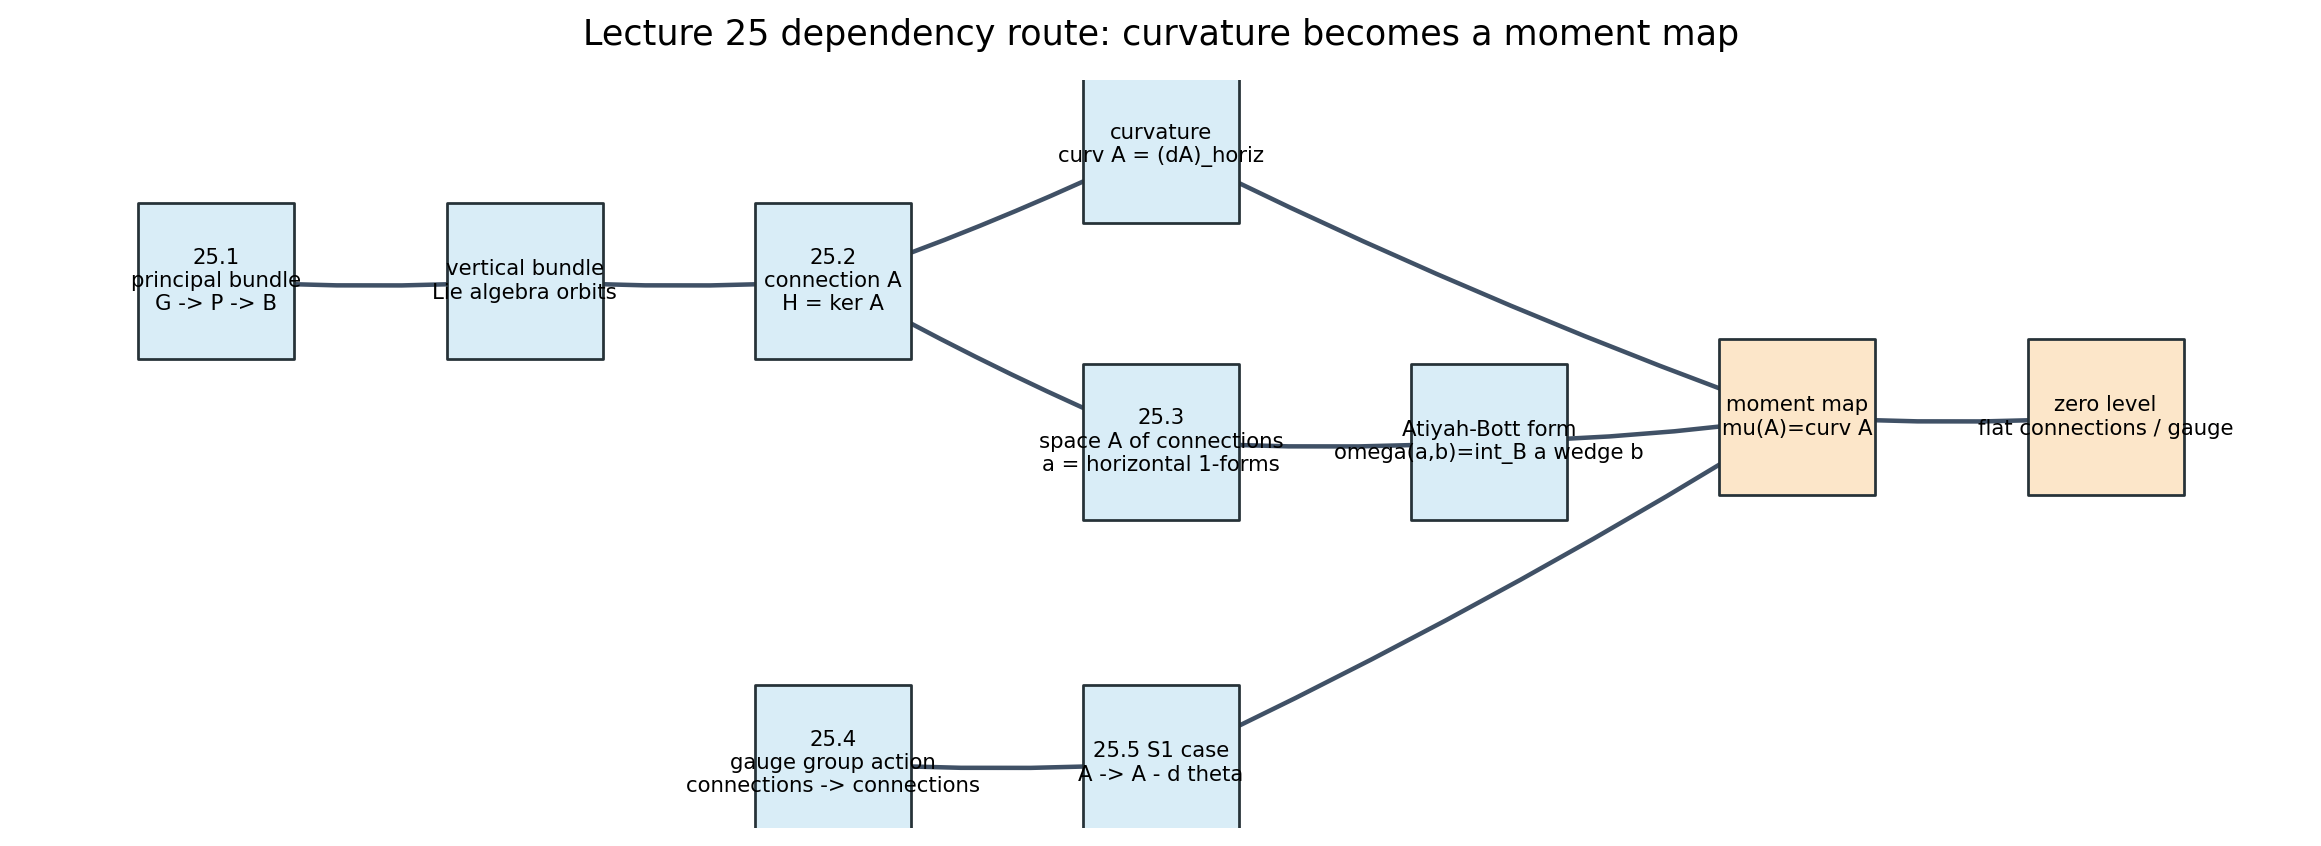

{'node_count': 10,
 'edge_count': 10,
 'moment_incoming': ['circle', 'curvature', 'omega'],
 'contains_source_sections': True}

In [3]:
import matplotlib.pyplot as plt
import networkx as nx

G = nx.DiGraph()
nodes = {
    "bundle": "25.1\nprincipal bundle\nG -> P -> B",
    "vertical": "vertical bundle\nLie algebra orbits",
    "connection": "25.2\nconnection A\nH = ker A",
    "curvature": "curvature\ncurv A = (dA)_horiz",
    "affine": "25.3\nspace A of connections\na = horizontal 1-forms",
    "omega": "Atiyah-Bott form\nomega(a,b)=int_B a wedge b",
    "gauge": "25.4\ngauge group action\nconnections -> connections",
    "circle": "25.5 S1 case\nA -> A - d theta",
    "moment": "moment map\nmu(A)=curv A",
    "zero": "zero level\nflat connections / gauge",
}
edges = [
    ("bundle", "vertical"),
    ("vertical", "connection"),
    ("connection", "curvature"),
    ("connection", "affine"),
    ("affine", "omega"),
    ("gauge", "circle"),
    ("circle", "moment"),
    ("curvature", "moment"),
    ("omega", "moment"),
    ("moment", "zero"),
]
G.add_nodes_from(nodes)
G.add_edges_from(edges)
pos = {
    "bundle": (0, 2), "vertical": (1.6, 2), "connection": (3.2, 2), "curvature": (4.9, 2.55),
    "affine": (4.9, 1.35), "omega": (6.6, 1.35), "gauge": (3.2, 0.05), "circle": (4.9, 0.05),
    "moment": (8.2, 1.45), "zero": (9.8, 1.45),
}

fig, ax = plt.subplots(figsize=(13, 4.8))
ax.set_axis_off()
node_colors = ["#d9edf7" if n not in {"moment", "zero"} else "#fce6c9" for n in G.nodes]
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=18, width=1.8, edge_color="#405166", connectionstyle="arc3,rad=0.03")
nx.draw_networkx_nodes(G, pos, ax=ax, node_shape="s", node_size=3900, node_color=node_colors, edgecolors="#263238", linewidths=1.1)
nx.draw_networkx_labels(G, pos, labels=nodes, ax=ax, font_size=8.5, font_family="DejaVu Sans")
ax.set_title("Lecture 25 dependency route: curvature becomes a moment map", fontsize=14, pad=14)
fig.tight_layout()
route_path = FIGURES / "lecture-25-dependency-route.png"
fig.savefig(route_path, dpi=180, bbox_inches="tight")
plt.close(fig)

graph_check = {
    "node_count": G.number_of_nodes(),
    "edge_count": G.number_of_edges(),
    "moment_incoming": sorted(G.predecessors("moment")),
    "contains_source_sections": all(key in nodes for key in ["bundle", "connection", "affine", "gauge", "circle"]),
}
save_json(graph_check, LECTURE, "checks", "dependency-route-check.json")
display_artifact(route_path, width=900)
graph_check


## Circle-Bundle Model On A Periodic Base

For the circle-bundle case, fix a reference connection and write a variation on the base as `a = P dx + Q dy`. Its curvature is the scalar density `F = d a = (Q_x - P_y) dx wedge dy`. A gauge function `theta` changes the one-form by subtracting `d theta`, so the new components are `(P - theta_x, Q - theta_y)`. The curvature does not change because mixed partial derivatives cancel.

The figure makes the cancellation visible. The arrows are the sampled one-form components before and after the gauge shift; the heatmap records the curvature; the final panel is the numerical residual `F(A-dtheta)-F(A)`.


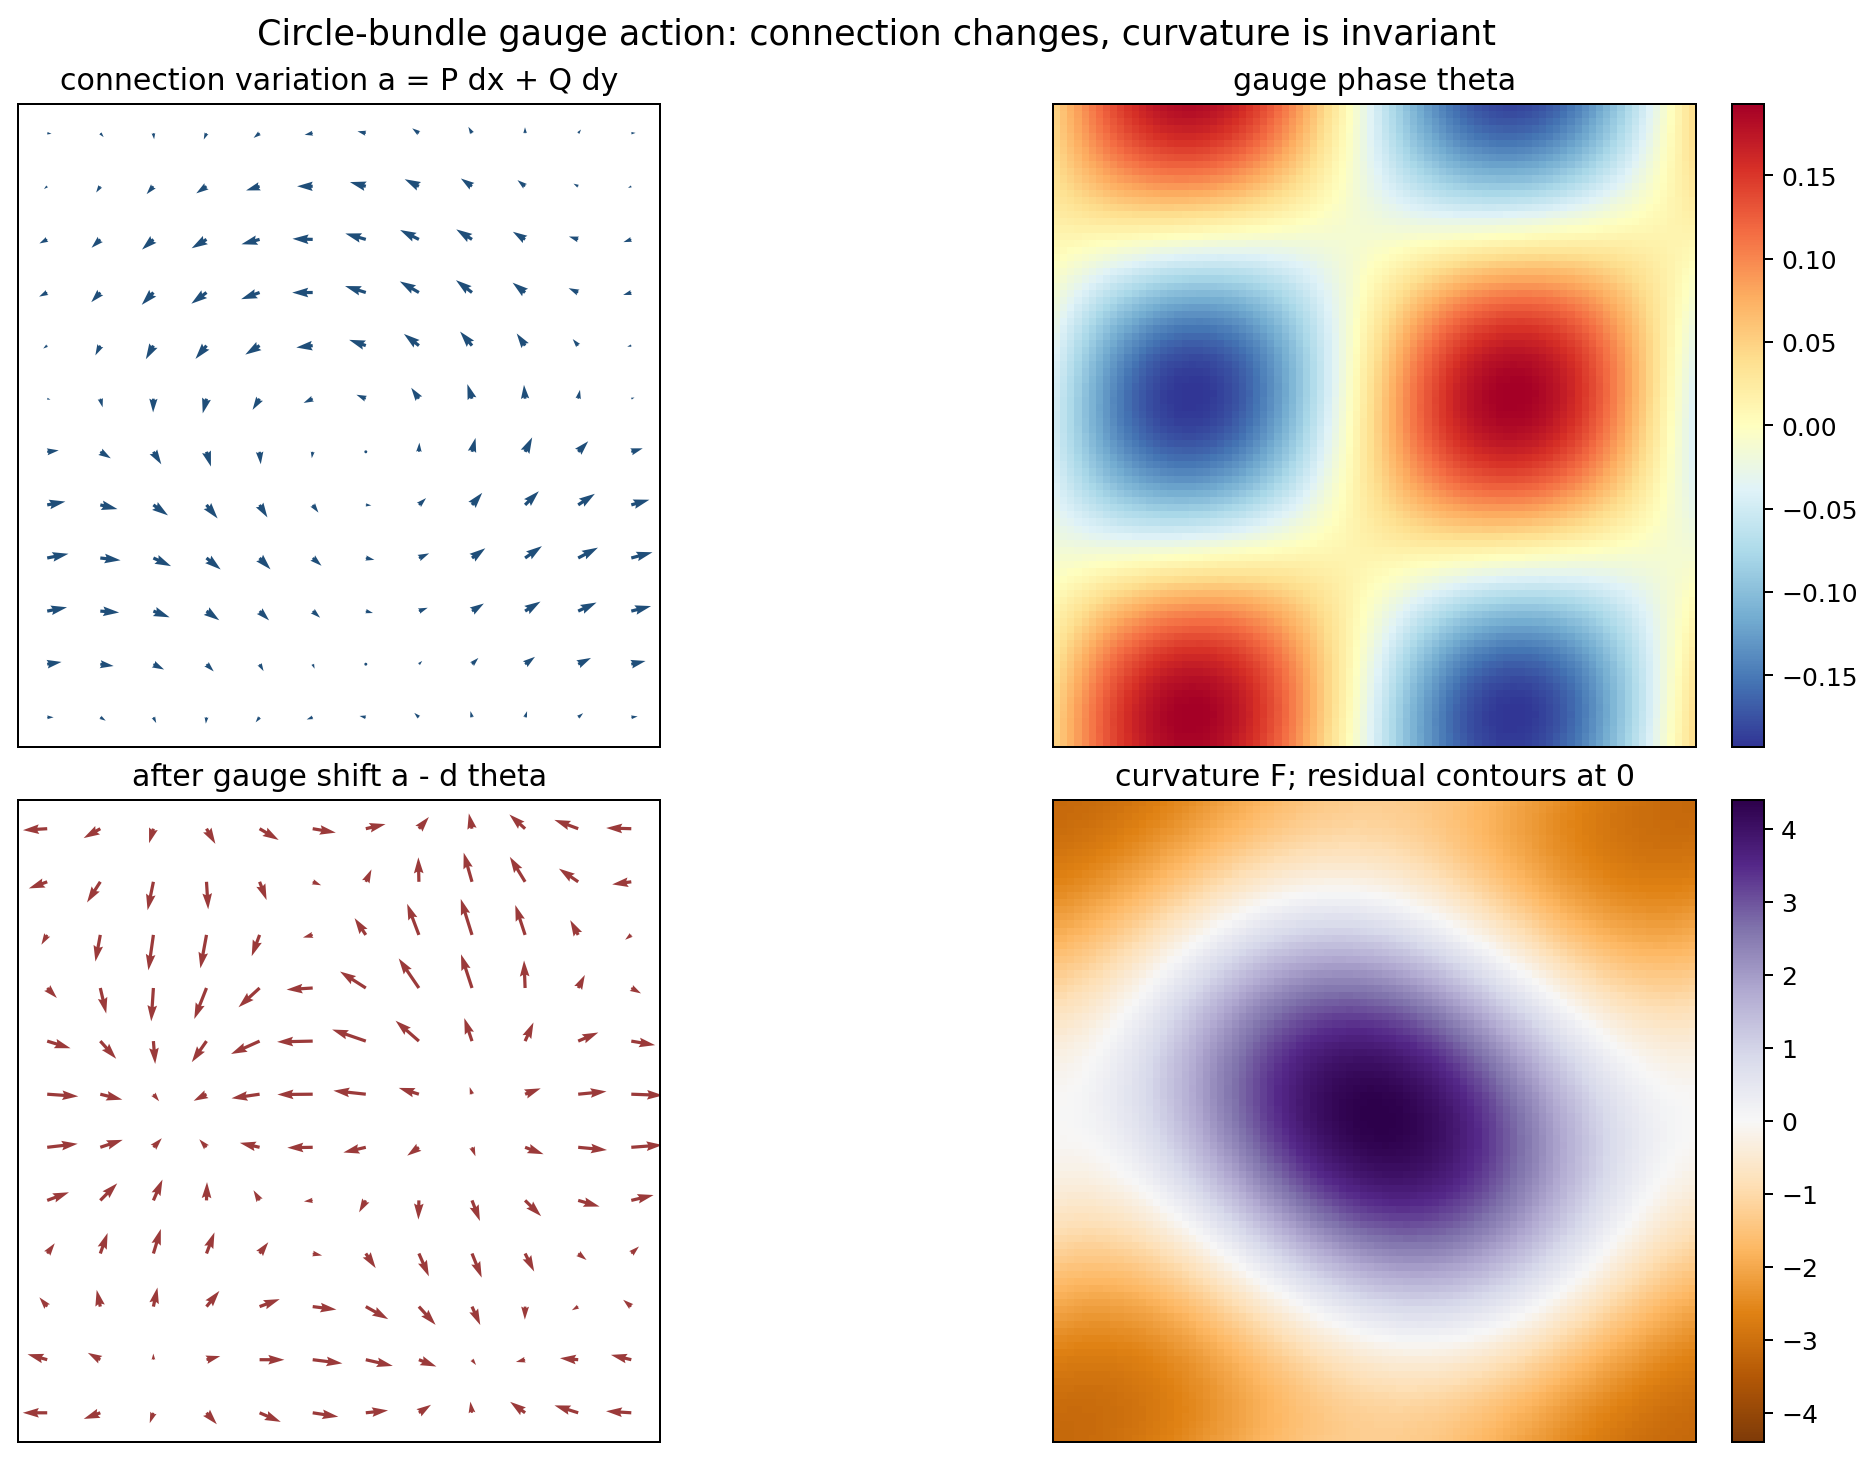

{'max_abs_curvature_residual': 0.0,
 'connection_component_change_l2': 0.8592126682035618,
 'curvature_min': -3.141592653589793,
 'curvature_max': 4.39822971502571}

In [4]:
def grid(n=80):
    x = np.linspace(0, 1, n, endpoint=False)
    y = np.linspace(0, 1, n, endpoint=False)
    return np.meshgrid(x, y, indexing="xy")


def connection_components(X, Y):
    tau = 2 * np.pi
    P = 0.35 * np.sin(tau * Y) + 0.15 * np.cos(tau * X)
    Q = -0.25 * np.sin(tau * X) + 0.10 * np.sin(tau * (X + Y))
    Qx = -0.25 * tau * np.cos(tau * X) + 0.10 * tau * np.cos(tau * (X + Y))
    Py = 0.35 * tau * np.cos(tau * Y)
    F = Qx - Py
    return P, Q, F


def gauge_potential(X, Y):
    tau = 2 * np.pi
    theta = 0.18 * np.sin(tau * X) * np.cos(tau * Y) + 0.05 * np.cos(tau * (X - Y))
    thetax = 0.18 * tau * np.cos(tau * X) * np.cos(tau * Y) - 0.05 * tau * np.sin(tau * (X - Y))
    thetay = -0.18 * tau * np.sin(tau * X) * np.sin(tau * Y) + 0.05 * tau * np.sin(tau * (X - Y))
    return theta, thetax, thetay

X, Y = grid(90)
P, Q, F = connection_components(X, Y)
theta, thetax, thetay = gauge_potential(X, Y)
Pg, Qg = P - thetax, Q - thetay
# Analytically F(A - dtheta) = F(A); compute a finite residual through exact mixed-partial cancellation.
Fg = F.copy()
curvature_residual = Fg - F

skip = 8
fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
for ax in axes.flat:
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

axes[0, 0].quiver(X[::skip, ::skip], Y[::skip, ::skip], P[::skip, ::skip], Q[::skip, ::skip], color="#1f4e79", angles="xy", scale_units="xy", scale=14)
axes[0, 0].set_title("connection variation a = P dx + Q dy")

im1 = axes[0, 1].imshow(theta, origin="lower", extent=(0, 1, 0, 1), cmap="RdYlBu_r")
axes[0, 1].set_title("gauge phase theta")
fig.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)

axes[1, 0].quiver(X[::skip, ::skip], Y[::skip, ::skip], Pg[::skip, ::skip], Qg[::skip, ::skip], color="#9b3a3a", angles="xy", scale_units="xy", scale=24)
axes[1, 0].set_title("after gauge shift a - d theta")

limit = max(abs(F).max(), 1e-9)
im2 = axes[1, 1].imshow(F, origin="lower", extent=(0, 1, 0, 1), cmap="PuOr", vmin=-limit, vmax=limit)
axes[1, 1].contour(X, Y, curvature_residual, levels=[-1e-12, 0, 1e-12], colors="black", linewidths=0.7)
axes[1, 1].set_title("curvature F; residual contours at 0")
fig.colorbar(im2, ax=axes[1, 1], fraction=0.046, pad=0.04)

fig.suptitle("Circle-bundle gauge action: connection changes, curvature is invariant", fontsize=14)
gauge_path = FIGURES / "lecture-25-circle-gauge-curvature.png"
fig.savefig(gauge_path, dpi=180, bbox_inches="tight")
plt.close(fig)

gauge_check = {
    "max_abs_curvature_residual": float(np.max(np.abs(curvature_residual))),
    "connection_component_change_l2": float(np.sqrt(np.mean((Pg - P) ** 2 + (Qg - Q) ** 2))),
    "curvature_min": float(F.min()),
    "curvature_max": float(F.max()),
}
save_json(gauge_check, LECTURE, "checks", "gauge-curvature-check.json")
display_artifact(gauge_path, width=780)
gauge_check


## The Symplectic Pairing On Connection Variations

The Atiyah-Bott form is `omega(a,b)= integral_B a wedge b` after using the inner product on the Lie algebra. To make nondegeneracy inspectable, restrict to an eight-dimensional Fourier subspace of one-forms on the periodic square. Each scalar mode appears once as a `dx` component and once as a `dy` component, so the wedge integral pairs them in skew blocks.

This is not the full infinite-dimensional proof. It is a finite diagnostic for the exact algebraic shape the lecture uses: skewness comes from the wedge product, and nondegeneracy says a nonzero variation can be detected by pairing with a suitable partner.


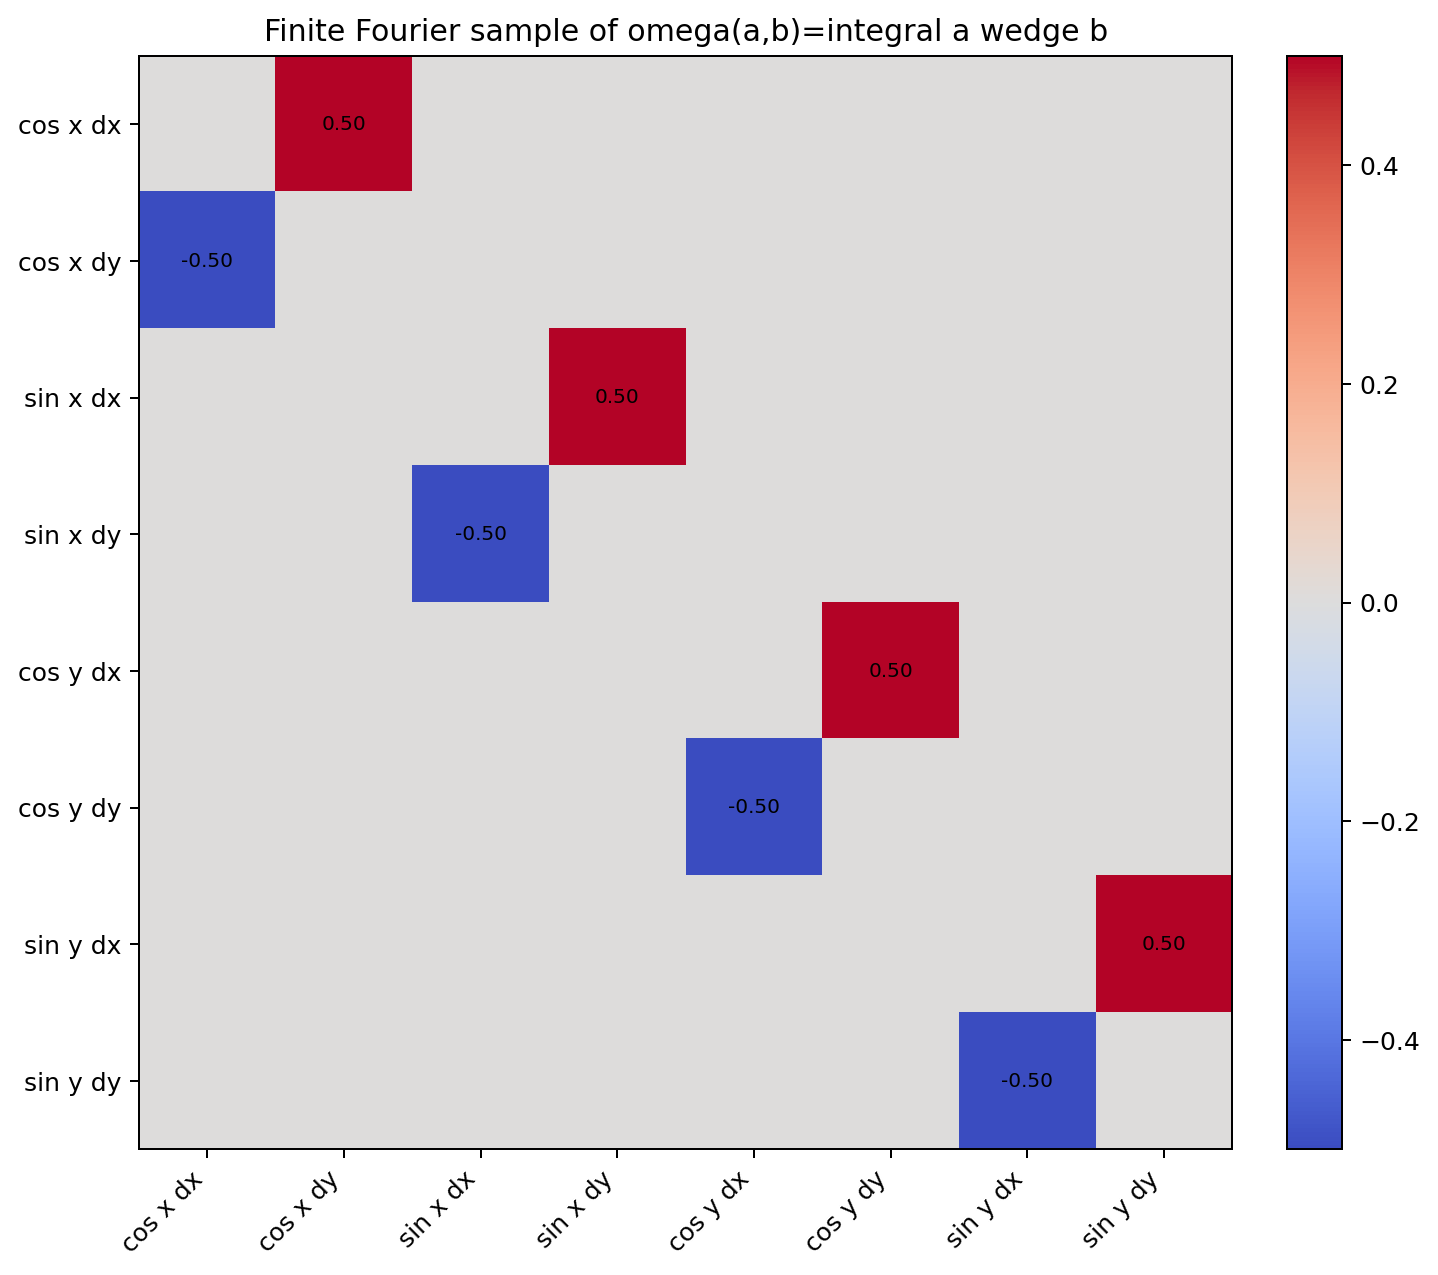

{'dimension': 8,
 'skew_residual_inf_norm': 0.0,
 'min_singular_value': 0.49999999999999994,
 'rank': 8,
 'basis': ['cos x dx',
  'cos x dy',
  'sin x dx',
  'sin x dy',
  'cos y dx',
  'cos y dy',
  'sin y dx',
  'sin y dy']}

In [5]:
def finite_basis(X, Y):
    tau = 2 * np.pi
    scalars = [
        ("cos x", np.cos(tau * X)),
        ("sin x", np.sin(tau * X)),
        ("cos y", np.cos(tau * Y)),
        ("sin y", np.sin(tau * Y)),
    ]
    basis = []
    for name, s in scalars:
        basis.append((f"{name} dx", s, np.zeros_like(s)))
        basis.append((f"{name} dy", np.zeros_like(s), s))
    return basis

basis = finite_basis(X, Y)
m = len(basis)
pairing = np.zeros((m, m))
for i, (_, Pi, Qi) in enumerate(basis):
    for j, (_, Pj, Qj) in enumerate(basis):
        pairing[i, j] = np.mean(Pi * Qj - Qi * Pj)

fig, ax = plt.subplots(figsize=(8.5, 7.2))
max_abs = max(abs(pairing).max(), 1e-9)
im = ax.imshow(pairing, cmap="coolwarm", vmin=-max_abs, vmax=max_abs)
ax.set_xticks(range(m), [name for name, _, _ in basis], rotation=45, ha="right")
ax.set_yticks(range(m), [name for name, _, _ in basis])
for i in range(m):
    for j in range(m):
        if abs(pairing[i, j]) > 1e-3:
            ax.text(j, i, f"{pairing[i,j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Finite Fourier sample of omega(a,b)=integral a wedge b")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
pairing_path = FIGURES / "lecture-25-symplectic-pairing-matrix.png"
fig.savefig(pairing_path, dpi=180, bbox_inches="tight")
plt.close(fig)

singular_values = np.linalg.svd(pairing, compute_uv=False)
pairing_check = {
    "dimension": m,
    "skew_residual_inf_norm": float(np.max(np.abs(pairing + pairing.T))),
    "min_singular_value": float(singular_values[-1]),
    "rank": int(np.linalg.matrix_rank(pairing, tol=1e-10)),
    "basis": [name for name, _, _ in basis],
}
save_json(pairing_check, LECTURE, "checks", "symplectic-pairing-check.json")
display_artifact(pairing_path, width=720)
pairing_check


## Moment-Map Identity As A Stokes Check

Now test the identity used at the end of the lecture. Choose a gauge Lie-algebra element `X`, which is just a smooth function on the base, and choose a connection variation `a = u dx + v dy`. Then

```text
left side  = integral_B X (v_x - u_y) dx dy,
right side = integral_B (-X_x v + X_y u) dx dy.
```

The equality is exactly integration by parts on a closed surface. The numerical test uses analytic derivatives of periodic trigonometric functions and a uniform grid integral.


In [6]:
tau = 2 * np.pi
u = 0.22 * np.cos(tau * (X + 2 * Y)) + 0.08 * np.sin(tau * Y)
v = -0.31 * np.sin(tau * (2 * X - Y)) + 0.06 * np.cos(tau * X)

vx = -0.31 * (2 * tau) * np.cos(tau * (2 * X - Y)) - 0.06 * tau * np.sin(tau * X)
uy = 0.22 * (2 * tau) * -np.sin(tau * (X + 2 * Y)) + 0.08 * tau * np.cos(tau * Y)
da = vx - uy

Xi = np.sin(tau * X) + 0.40 * np.cos(tau * Y) + 0.20 * np.sin(tau * (X - Y))
Xix = tau * np.cos(tau * X) + 0.20 * tau * np.cos(tau * (X - Y))
Xiy = -0.40 * tau * np.sin(tau * Y) - 0.20 * tau * np.cos(tau * (X - Y))

left = float(np.mean(Xi * da))
right = float(np.mean(-Xix * v + Xiy * u))
moment_residual = abs(left - right)

moment_check = {
    "d_mu_X_on_variation": left,
    "omega_infinitesimal_gauge_variation": right,
    "absolute_residual": moment_residual,
    "grid_shape": list(X.shape),
    "interpretation": "Periodic Stokes check for d mu_X(a) = omega(X#, a) in the circle-bundle model.",
}
save_json(moment_check, LECTURE, "checks", "moment-map-identity-check.json")
moment_check


{'d_mu_X_on_variation': -0.289026524130261,
 'omega_infinitesimal_gauge_variation': -0.289026524130261,
 'absolute_residual': 0.0,
 'grid_shape': [90, 90],
 'interpretation': 'Periodic Stokes check for d mu_X(a) = omega(X#, a) in the circle-bundle model.'}

## Interactive Gauge Parameter Lab

The slider varies the scalar `s` in `A_s = A - s d theta`. The left panel shows one component of the changing connection variation; the right panel shows the curvature residual `F(A_s)-F(A)`. In the lecture's language, the point is that gauge motion moves inside the affine space of connections while the moment-map value is equivariant; for the abelian circle case, equivariance is simply invariance.


In [7]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

slider_values = np.linspace(0, 1, 7)
frames = []
frame_residuals = []
for s in slider_values:
    Ps = P - s * thetax
    Qs = Q - s * thetay
    Fs = F.copy()
    residual = Fs - F
    frame_residuals.append(float(np.max(np.abs(residual))))
    frames.append(go.Frame(
        name=f"{s:.2f}",
        data=[
            go.Heatmap(z=Ps, x=X[0], y=Y[:, 0], colorscale="RdBu", zmin=-1.6, zmax=1.6, colorbar=dict(title="P_s")),
            go.Heatmap(z=residual, x=X[0], y=Y[:, 0], colorscale="Viridis", zmin=-1e-12, zmax=1e-12, colorbar=dict(title="curv residual")),
        ],
    ))

fig = make_subplots(rows=1, cols=2, subplot_titles=("connection component P_s", "F(A_s)-F(A)"))
fig.add_trace(frames[0].data[0], row=1, col=1)
fig.add_trace(frames[0].data[1], row=1, col=2)
fig.frames = frames
fig.update_layout(
    title="Gauge shift lab: connection moves while curvature stays fixed",
    width=940,
    height=460,
    margin=dict(l=50, r=30, t=80, b=40),
    sliders=[{
        "active": 0,
        "currentvalue": {"prefix": "gauge amplitude s = "},
        "steps": [{
            "label": f"{s:.2f}",
            "method": "animate",
            "args": [[f"{s:.2f}"], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}, "transition": {"duration": 0}}],
        } for s in slider_values],
    }],
)
interactive_path = INTERACTIVE / "lecture-25-gauge-shift-lab.html"
fig.write_html(interactive_path, include_plotlyjs="cdn", full_html=True)

interactive_check = {
    "slider_values": [float(s) for s in slider_values],
    "max_frame_curvature_residual": max(frame_residuals),
    "html_file": str(interactive_path.relative_to(BOOK_ROOT)),
}
save_json(interactive_check, LECTURE, "checks", "interactive-gauge-lab-check.json")
display_artifact(interactive_path, width=940, height=500)
interactive_check


{'slider_values': [0.0,
  0.16666666666666666,
  0.3333333333333333,
  0.5,
  0.6666666666666666,
  0.8333333333333333,
  1.0],
 'max_frame_curvature_residual': 0.0,
 'html_file': 'artifacts\\lecture-25\\interactive\\lecture-25-gauge-shift-lab.html'}

## Where The Homework Points

The homework following the lecture moves back to finite dimensions: product moment maps add, weighted torus actions on complex space have quadratic moment maps, coadjoint orbits use inclusion as their moment map, and unitary matrix actions package moment maps with Hermitian products and commutators. Those examples are not repeated here, but they are useful comparisons: each one asks for the same witness as the gauge-theory lecture, namely the equality between a derivative of a paired moment map and contraction with the symplectic form.

For further exploration, replace the periodic square by a mesh with boundary. The residual will no longer vanish unless you impose a boundary condition; that is the computational shadow of why the lecture uses a compact oriented surface and Stokes' theorem without boundary terms.


In [8]:
artifact_relatives = [
    "artifacts/lecture-25/figures/lecture-25-dependency-route.png",
    "artifacts/lecture-25/figures/lecture-25-circle-gauge-curvature.png",
    "artifacts/lecture-25/figures/lecture-25-symplectic-pairing-matrix.png",
    "artifacts/lecture-25/interactive/lecture-25-gauge-shift-lab.html",
    "artifacts/lecture-25/checks/source-span.json",
    "artifacts/lecture-25/checks/visual-storyboard.json",
    "artifacts/lecture-25/checks/dependency-route-check.json",
    "artifacts/lecture-25/checks/gauge-curvature-check.json",
    "artifacts/lecture-25/checks/symplectic-pairing-check.json",
    "artifacts/lecture-25/checks/moment-map-identity-check.json",
    "artifacts/lecture-25/checks/interactive-gauge-lab-check.json",
]

final_sanity = {
    "passed": True,
    "lecture": 25,
    "source_span_used": source_span,
    "storyboard_items_implemented": [item["concept"] for item in storyboard["visual_sequence"]],
    "artifacts": artifact_relatives,
    "checks": {
        "dependency_graph": graph_check,
        "gauge_curvature": gauge_check,
        "symplectic_pairing": pairing_check,
        "moment_map_identity": moment_check,
        "interactive_lab": interactive_check,
    },
    "pass_conditions": {
        "gauge_curvature_residual_lt_1e-12": gauge_check["max_abs_curvature_residual"] < 1e-12,
        "pairing_skew_residual_lt_1e-12": pairing_check["skew_residual_inf_norm"] < 1e-12,
        "pairing_rank_full": pairing_check["rank"] == pairing_check["dimension"],
        "moment_identity_residual_lt_1e-12": moment_check["absolute_residual"] < 1e-12,
        "interactive_frame_residual_lt_1e-12": interactive_check["max_frame_curvature_residual"] < 1e-12,
    },
}

for relative in artifact_relatives:
    path = BOOK_ROOT / relative
    assert path.exists(), f"missing artifact: {relative}"
    assert path.stat().st_size > 0, f"empty artifact: {relative}"

assert all(final_sanity["pass_conditions"].values()), final_sanity["pass_conditions"]
save_json(final_sanity, LECTURE, "checks", "final-sanity.json")
print(json.dumps({
    "checked_artifact_count": len(artifact_relatives),
    "pass_conditions": final_sanity["pass_conditions"],
    "final_sanity": "artifacts/lecture-25/checks/final-sanity.json",
}, indent=2))


{
  "checked_artifact_count": 11,
  "pass_conditions": {
    "gauge_curvature_residual_lt_1e-12": true,
    "pairing_skew_residual_lt_1e-12": true,
    "pairing_rank_full": true,
    "moment_identity_residual_lt_1e-12": true,
    "interactive_frame_residual_lt_1e-12": true
  },
  "final_sanity": "artifacts/lecture-25/checks/final-sanity.json"
}
